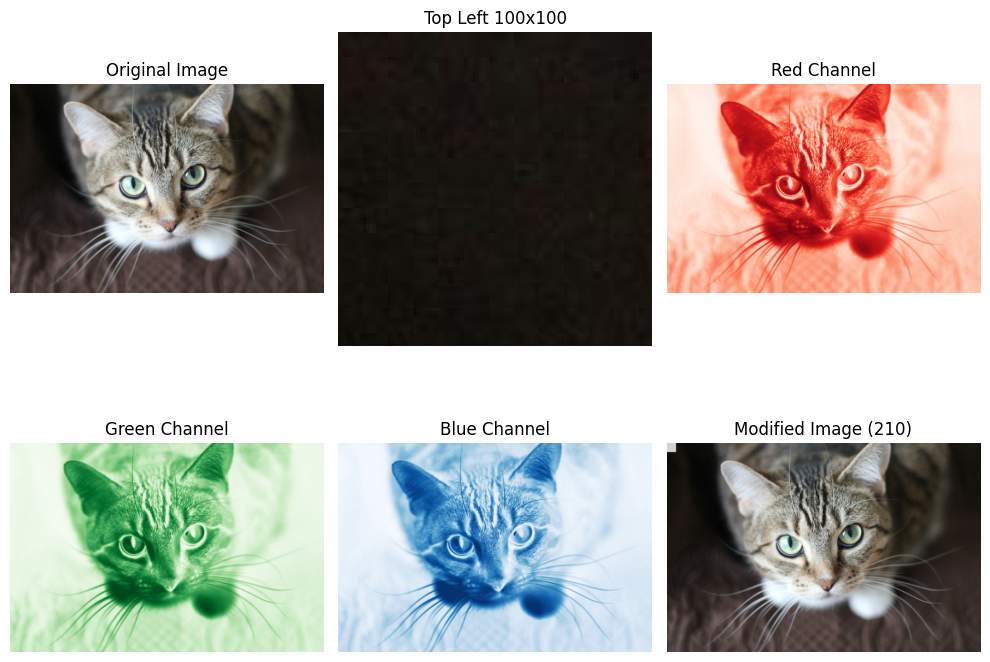

In [6]:
# Exercise 1
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

# Read and display the image
img = Image.open('image.jpg')
img_array = np.array(img)

plt.figure(figsize=(10,8))

# 1. Original Image
plt.subplot(2,3,1)
plt.imshow(img_array)
plt.title("Original Image")
plt.axis('off')

# 2. Top Left 100x100 pixels
top_left = img_array[0:100, 0:100, :]

plt.subplot(2,3,2)
plt.imshow(top_left)
plt.title("Top Left 100x100")
plt.axis('off')

# 3. Separate RGB Channels
R = img_array[:,:,0]
G = img_array[:,:,1]
B = img_array[:,:,2]

# Red Channel
plt.subplot(2,3,3)
plt.imshow(R, cmap='Reds')
plt.title("Red Channel")
plt.axis('off')

# Green Channel
plt.subplot(2,3,4)
plt.imshow(G, cmap='Greens')
plt.title("Green Channel")
plt.axis('off')

# Blue Channel
plt.subplot(2,3,5)
plt.imshow(B, cmap='Blues')
plt.title("Blue Channel")
plt.axis('off')

# 4. Modify top 100x100 pixels to value 210
modified_img = img_array.copy()
modified_img[0:100,0:100,:] = 210

plt.subplot(2,3,6)
plt.imshow(modified_img)
plt.title("Modified Image (210)")
plt.axis('off')

plt.tight_layout()
plt.show()

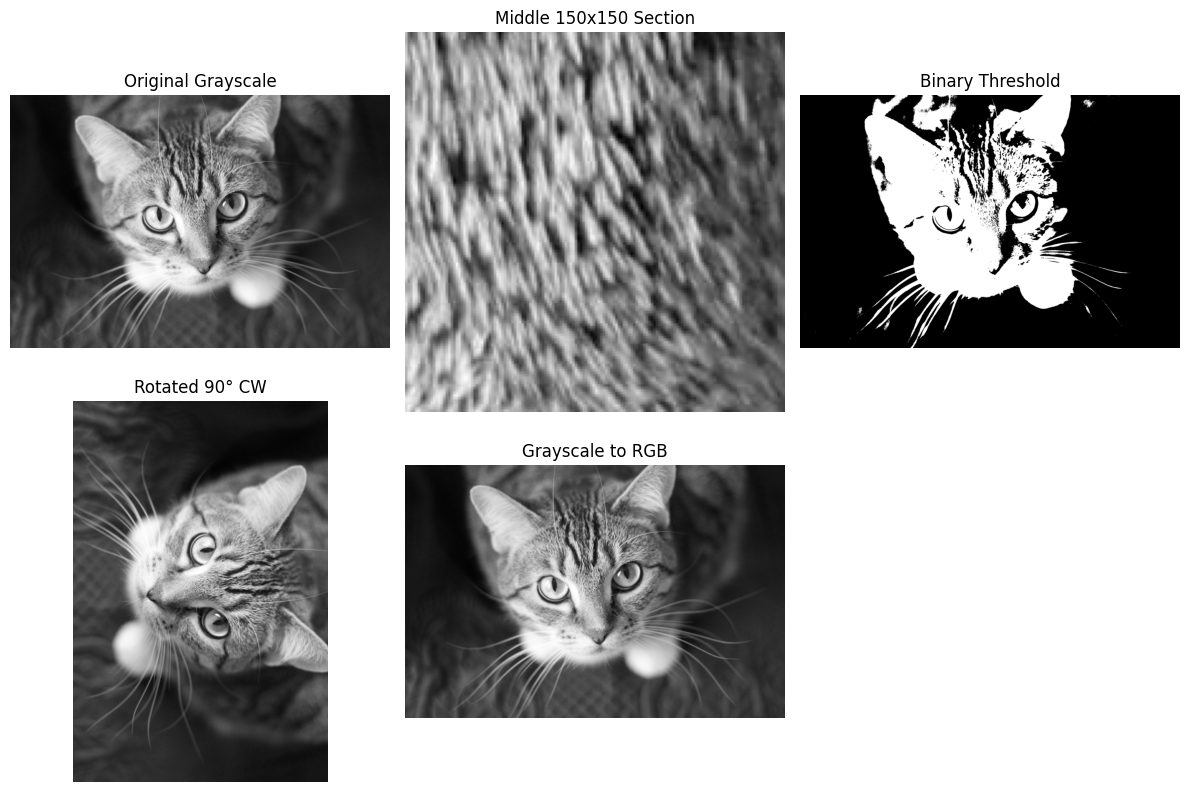

In [7]:
# Exercise 2
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

# Load and display a grayscale image
img_gray = Image.open('image.jpg').convert('L')
img_array = np.array(img_gray)

plt.figure(figsize=(12,8))

# 1. Original Grayscale Image
plt.subplot(2,3,1)
plt.imshow(img_array, cmap='gray')
plt.title("Original Grayscale")
plt.axis('off')

# 2. Extract middle 150x150 section
h, w = img_array.shape
center_h, center_w = h//2, w//2

middle = img_array[center_h-75:center_h+75, center_w-75:center_w+75]

plt.subplot(2,3,2)
plt.imshow(middle, cmap='gray')
plt.title("Middle 150x150 Section")
plt.axis('off')

# 3. Apply threshold (binary image)
binary_img = np.where(img_array > 100, 255, 0).astype(np.uint8)

plt.subplot(2,3,3)
plt.imshow(binary_img, cmap='gray')
plt.title("Binary Threshold")
plt.axis('off')

# 4. Rotate 90 degrees clockwise
rotated_img = img_gray.rotate(-90, expand=True)

plt.subplot(2,3,4)
plt.imshow(rotated_img, cmap='gray')
plt.title("Rotated 90° CW")
plt.axis('off')

# 5. Convert grayscale to RGB
rgb_img = np.stack([img_array]*3, axis=-1)

plt.subplot(2,3,5)
plt.imshow(rgb_img)
plt.title("Grayscale to RGB")
plt.axis('off')

plt.tight_layout()
plt.show()

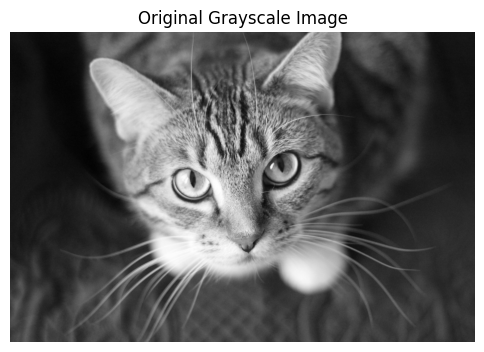

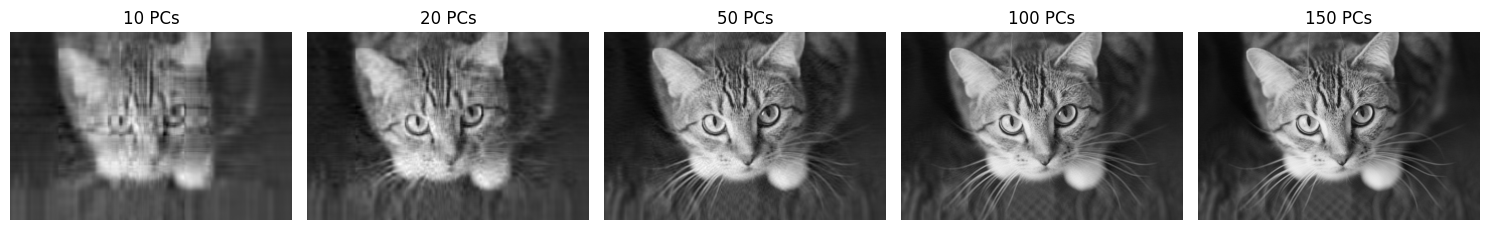

In [8]:
# Exercise 3
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

# Load Image and Convert to Grayscale
img = Image.open('image.jpg').convert('L')
data = np.array(img, dtype=float)

# Display Original Image
plt.figure(figsize=(6,6))
plt.imshow(data, cmap='gray')
plt.title("Original Grayscale Image")
plt.axis('off')
plt.show()

# Center the Data (Standardization Step)
mean = np.mean(data, axis=0)
data_centered = data - mean

# Covariance Matrix
cov_matrix = np.cov(data_centered, rowvar=False)

# Eigen Decomposition
eigen_values, eigen_vectors = np.linalg.eigh(cov_matrix)

# Sort Eigenvalues and Eigenvectors in Descending Order
idx = np.argsort(eigen_values)[::-1]
eigen_values = eigen_values[idx]
eigen_vectors = eigen_vectors[:, idx]

# Function to Rebuild Image using Top k Principal Components
def rebuild(k):
    top_vectors = eigen_vectors[:, :k]
    compressed = np.dot(data_centered, top_vectors)
    reconstructed = np.dot(compressed, top_vectors.T) + mean
    return reconstructed

# Display Reconstructed Images with Different Principal Components
k_values = [10, 20, 50, 100, 150]

plt.figure(figsize=(15,4))

for i, k in enumerate(k_values):
    plt.subplot(1, len(k_values), i+1)
    plt.imshow(rebuild(k), cmap='gray')
    plt.title(f"{k} PCs")
    plt.axis('off')

plt.tight_layout()
plt.show()